In [ ]:
import os

In [ ]:
print(len(os.listdir("/content/drive/MyDrive/VideoTensors/videoTensorFull/videosTensors1000")))
print(len(os.listdir("/content/drive/MyDrive/VideoTensors/Test/Test")))

8480
4242


In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import os
import pandas as pd
import numpy as np
import random


import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import os
import pandas as pd
import numpy as np
import random

class MotionDataset(Dataset):
    def __init__(self, df: pd.DataFrame, pt_folder: str, training: bool = True,
                 max_points: int = 1000, augment_prob: float = 0.7):
        self.df = df.reset_index(drop=True)
        self.pt_folder = pt_folder
        self.training = training
        self.max_points = max_points
        self.augment_prob = augment_prob
        print(f"Initialized MotionDataset with {len(self.df)} samples. Training: {self.training}")

    def __len__(self) -> int:
        return len(self.df)

    def _normalize_coordinates(self, coords: torch.Tensor, height: float = 384.0, width: float = 512.0) -> torch.Tensor:
        coords_norm = coords.clone()
        coords_norm[..., 0] = coords_norm[..., 0] / width   # x
        coords_norm[..., 1] = coords_norm[..., 1] / height  # y

        # Clamp to reasonable range to handle outliers
        coords_norm = torch.clamp(coords_norm, -0.1, 1.1)
        return coords_norm

    def _calculate_features(self, coords: torch.Tensor, visibility: torch.Tensor) -> torch.Tensor:
        seq_len, num_points, _ = coords.shape

        # Velocity (first derivative)
        velocity = torch.zeros_like(coords)
        if seq_len > 1:
            velocity[1:] = coords[1:] - coords[:-1]

        acceleration = torch.zeros_like(coords)
        if seq_len > 2:
            acceleration[2:] = velocity[2:] - velocity[1:-1]

        # Direction change (angle between consecutive velocity vectors)
        direction_change = torch.zeros(seq_len, num_points, 1)
        if seq_len > 2:
            for t in range(2, seq_len):
                v1 = velocity[t-1]
                v2 = velocity[t]
                # Calculate angle between vectors using cos (theta) = (v1 . v2) / (||v1|| * ||v2||)
                dot_product = (v1 * v2).sum(dim=-1, keepdim=True)
                norms = torch.norm(v1, dim=-1, keepdim=True) * torch.norm(v2, dim=-1, keepdim=True)
                cos_angle = dot_product / (norms + 1e-8)
                cos_angle = torch.clamp(cos_angle, -1, 1)
                direction_change[t] = torch.acos(cos_angle)

        # Combine all features: [x, y, visibility, vel_x, vel_y, speed, acc_x, acc_y, direction_change]
        features = torch.cat([
            coords,           # x, y
            visibility,       # visibility
            velocity,         # vel_x, vel_y
            acceleration,     # acc_x, acc_y
            direction_change  # direction change
        ], dim=-1)

        return features

    def __getitem__(self, idx: int) -> tuple:
        row = self.df.iloc[idx]
        vid_name, label = row['vid_name'], row['label']

        pt_path = os.path.join(self.pt_folder, f"{vid_name}_tracking.pt")

        try:
            data = torch.load(pt_path, map_location='cpu')
        except Exception as e:
            print(f"Error loading {pt_path}: {e}")
            # Return a dummy tensor for failed loads
            return (torch.zeros(10, self.max_points, 9),
                   torch.tensor(0).long(),
                   torch.ones(10, dtype=torch.bool),
                   "error_vid")

        seg_len, num_points = data['shape_info']

        # Load and normalize coordinates
        pred_tracks = data['pred_tracks'].view(seg_len, num_points, 2)
        coords = self._normalize_coordinates(pred_tracks)

        # Load visibility
        pred_vis = data['pred_visibility'].view(seg_len, num_points, 1)
        pred_vis = pred_vis.float()

        input_tensor = self._calculate_features(coords, pred_vis)

        return input_tensor, torch.tensor(label).long(), vid_name

def motion_collate_fn(batch: list) -> tuple:
    features, labels, video_names = zip(*batch)
    lengths = torch.tensor([s.shape[0] for s in features])
    features_padded = pad_sequence(features, batch_first=True, padding_value=0.0)
    max_len = features_padded.shape[1]
    mask = torch.arange(max_len).expand(len(lengths), max_len) >= lengths.unsqueeze(1)
    labels_tensor = torch.stack(labels)
    return features_padded, labels_tensor, mask, video_names


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PointTemporalEncoder(nn.Module):
    """Encodes each point's temporal dynamics via 1D CNN with masking"""
    def __init__(self, input_dim=9, hidden_dim=128):
        super().__init__()
        self.temporal_conv = nn.Sequential(
            nn.Conv1d(input_dim, hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU()
        )

    def forward(self, x, mask=None):  # x: [B, N, T, C], mask: [B, T]
        B, N, T, C = x.shape
        x = x.reshape(B * N, T, C).permute(0, 2, 1)  # → [B*N, C, T]
        out = self.temporal_conv(x)  # → [B*N, D, T]

        if mask is not None:
            # Expand mask for all points: [B, T] → [B*N, T]
            expanded_mask = mask.unsqueeze(1).expand(B, N, T).contiguous().view(B * N, T)
            # Set padded positions to zero: [B*N, D, T]
            out = out * (~expanded_mask).unsqueeze(1).float()

            # Masked average pooling
            valid_lengths = (~expanded_mask).sum(dim=1, keepdim=True).float()  # [B*N, 1]
            valid_lengths = torch.clamp(valid_lengths, min=1.0)  # Avoid division by zero
            out = out.sum(dim=2) / valid_lengths  # → [B*N, D]
        else:
            out = torch.mean(out, dim=2)  # → [B*N, D]

        return out.view(B, N, -1)  # → [B, N, D]

class PointAggregator(nn.Module):
    """Aggregates across points via transformer"""
    def __init__(self, point_dim=128, nhead=4, num_layers=2, dim_feedforward=256):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=point_dim,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, x, mask=None):  # x: [B, N, D]
        # Note: The mask here is for temporal dimension, but we're aggregating across points (N)
        # The transformer operates on the point dimension, not temporal
        # So we don't need to pass the temporal mask to the transformer

        out = self.transformer(x)  # → [B, N, D]
        return out.mean(dim=1)  # Global average pooling → [B, D]

class HierarchicalMotionClassifier(nn.Module):
    def __init__(self, input_dim=8, temporal_dim=128, num_classes=47):
        super().__init__()
        self.temporal_encoder = PointTemporalEncoder(input_dim=input_dim, hidden_dim=temporal_dim)
        self.aggregator = PointAggregator(point_dim=temporal_dim)
        self.classifier = nn.Sequential(
            nn.Linear(temporal_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x, mask=None):  # x: [B, T, N, C], mask: [B, T]
        x = x.permute(0, 2, 1, 3)  # → [B, N, T, C]
        point_features = self.temporal_encoder(x, mask)  # → [B, N, D]
        global_repr = self.aggregator(point_features)  # → [B, D]
        return self.classifier(global_repr)

In [ ]:
# device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
# improved_training.py - Improved training script with better hyperparameters and techniques

import torch
import torch.nn as nn
import pandas as pd
import os
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from tqdm import tqdm
from torch.utils.data import WeightedRandomSampler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import warnings


class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.001, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_loss = None
        self.counter = 0
        self.best_weights = None

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.save_checkpoint(model)
        else:
            self.counter += 1

        if self.counter >= self.patience:
            if self.restore_best_weights:
                model.load_state_dict(self.best_weights)
            return True
        return False

    def save_checkpoint(self, model):
        self.best_weights = model.state_dict().copy()

def calculate_class_weights(train_df, num_classes, power=0.5):
    """Calculate class weights with smoothing"""
    class_counts = train_df['label'].value_counts().sort_index()
    total_samples = len(train_df)

    # Calculate weights with smoothing
    weights = []
    for i in range(num_classes):
        count = class_counts.get(i, 1)  # Use 1 if class doesn't exist
        weight = (total_samples / (num_classes * count)) ** power
        weights.append(weight)

    weights = torch.tensor(weights, dtype=torch.float32)
    return weights / weights.sum() * num_classes  # Normalize

def train_and_evaluate_improved(train_loader, val_loader, model, optimizer, criterion,
                               device, scheduler, num_classes, num_epochs, early_stopping=None):

    print("Starting improved training...")
    best_accuracy = 0.0
    best_f1 = 0.0
    train_losses = []
    val_accuracies = []

    os.makedirs("saved_models", exist_ok=True)
    print(f"Starting Epochs")
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        total_loss = 0
        num_correct = 0
        num_samples = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
        print(f"Device inside is {device}")
        for i, (features, labels, mask, _) in enumerate(pbar):
            features = features.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            mask = mask.to(device, non_blocking=True)
            # print(f"Feature shape: {features.shape}, Labels: {labels.shape}, maskL {mask.shape}")
            # print(f"Shape {features.shape}, {labels.shape}, {mask.shape}")
            # Forward pass
            outputs = model(features, mask)
            loss = criterion(outputs, labels)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            num_samples += labels.size(0)
            num_correct += (predicted == labels).sum().item()

            # Update progress bar
            current_acc = 100 * num_correct / num_samples
            pbar.set_postfix({
                'Loss': f'{total_loss/(i+1):.4f}',
                'Acc': f'{current_acc:.2f}%',
                'LR': f'{scheduler.get_last_lr()[0]:.2e}'
            })

        avg_train_loss = total_loss / len(train_loader)
        train_accuracy = 100 * num_correct / num_samples

        # Validation phase
        model.eval()
        val_loss = 0
        val_correct = 0
        val_samples = 0
        all_predictions = []
        all_labels = []

        with torch.no_grad():
            for features, labels, mask, _ in tqdm(val_loader, desc="Validating"):
                features = features.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                mask = mask.to(device, non_blocking=True)

                outputs = model(features, mask)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_samples += labels.size(0)
                val_correct += (predicted == labels).sum().item()

                all_predictions.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = 100 * val_correct / val_samples


        # Calculate F1 score
        from sklearn.metrics import f1_score
        val_f1 = f1_score(all_labels, all_predictions, average='weighted') * 100
        print(device)
        # Log results
        print(f"\nEpoch [{epoch+1}/{num_epochs}]:")
        print(f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}%")
        print(f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%, Val F1: {val_f1:.2f}%")
        print(f"Learning Rate: {scheduler.get_last_lr()[0]:.2e}")

        # Save best model
        if val_accuracy > best_accuracy or (val_accuracy == best_accuracy and val_f1 > best_f1):
            best_accuracy = val_accuracy
            best_f1 = val_f1
            save_path = os.path.join("saved_models", 'best_motion_classifier_model.pth')
            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'epoch': epoch,
                'best_accuracy': best_accuracy,
                'best_f1': best_f1,
            }, save_path)
            print(f"🎉 New best model saved! Acc: {best_accuracy:.2f}%, F1: {best_f1:.2f}%")

        # Early stopping
        if early_stopping and early_stopping(avg_val_loss, model):
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

        train_losses.append(avg_train_loss)
        val_accuracies.append(val_accuracy)
        print("="*80)

    print(f"Training finished. Best validation accuracy: {best_accuracy:.2f}%, Best F1: {best_f1:.2f}%")

    # Plot training curves
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses)
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')

    plt.subplot(1, 2, 2)
    plt.plot(val_accuracies)
    plt.title('Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

    return best_accuracy, best_f1



In [ ]:
BATCH_SIZE = 16

In [ ]:
# Device configuration
# print(len(os.listdir("/content/drive/MyDrive/VideoTensors/videoTensorFull/videosTensors1000")))
# print(len(os.listdir("/content/drive/MyDrive/VideoTensors/Test/Test")))

# Data paths (update these to your paths)
TRAIN_PT_FOLDER = "/content/drive/MyDrive/VideoTensors/videoTensorFull/videosTensors1000"
TRAIN_DF_PATH = "/content/df_exists1.csv"
TEST_PT_FOLDER = "/content/drive/MyDrive/VideoTensors/Test/Test"
TEST_DF_PATH = "/content/ProcessedTestCorrect.csv"

# Load data
print("Loading data...")
train_df = pd.read_csv(TRAIN_DF_PATH)
val_df = pd.read_csv(TEST_DF_PATH)

# Label mapping
original_labels = sorted(pd.concat([train_df['label'], val_df['label']]).unique())
label_mapping = {orig_label: i for i, orig_label in enumerate(original_labels)}
train_df['label'] = train_df['label'].map(label_mapping)
val_df['label'] = val_df['label'].map(label_mapping).dropna().astype(int)
NUM_CLASSES = len(label_mapping)
print(f"Number of classes: {NUM_CLASSES}")

# Check class distribution
print("Class distribution in training set:")
print(train_df['label'].value_counts().sort_index())

# Create weighted sampler with less aggressive resampling
print("Creating balanced sampler...")
class_counts = train_df['label'].value_counts().sort_index()
class_weights = calculate_class_weights(train_df, NUM_CLASSES, power=0.3)  # Less aggressive
print(train_df['label'].map(lambda x: class_weights[x]).unique())
print(train_df['label'].map(lambda x: class_weights[x]).apply(type).unique())
sample_weights = train_df['label'].map(lambda x: class_weights[x]).astype(float).to_numpy()
sample_weights = torch.from_numpy(sample_weights).float()
train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Create datasets and dataloaders
train_dataset = MotionDataset(train_df, TRAIN_PT_FOLDER, training=True)
val_dataset = MotionDataset(val_df, TEST_PT_FOLDER, training=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    collate_fn=motion_collate_fn,
    num_workers=4,  # Reduced for stability
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,  # Larger batch size for validation
    shuffle=False,
    collate_fn=motion_collate_fn,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

# Try both models - start with the simpler one
print("Testing Simple Model first...")


Loading data...
Number of classes: 47
Class distribution in training set:
label
0     145
1      74
2      16
3     115
4      44
5     192
6     101
7     494
8     200
9      49
10     26
11     80
12    209
13     15
14     33
15    283
16     52
17     90
18     33
19    212
20     32
21    279
22    212
23     33
24    203
25     42
26    468
27    100
28    174
29    102
30    264
31     71
32    293
33    280
34    486
35    183
36     30
37     22
38     20
39     31
40     54
41     76
42    217
43    202
44    337
45    340
46     55
Name: count, dtype: int64
Creating balanced sampler...
[tensor(0.8517) tensor(0.8517) tensor(0.8517) ... tensor(1.1392)
 tensor(1.1392) tensor(1.1392)]
[<class 'torch.Tensor'>]
Initialized MotionDataset with 7069 samples. Training: True
Initialized MotionDataset with 3337 samples. Training: False
Train batches: 442, Val batches: 209
Testing Simple Model first...


In [ ]:
model = HierarchicalMotionClassifier(input_dim=8, num_classes=47).cuda()
class_weights_loss = calculate_class_weights(train_df, NUM_CLASSES, power=0.25)
criterion = nn.CrossEntropyLoss(
  weight=class_weights_loss.to("cuda"),
  label_smoothing=0.05
)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

early_stopping = EarlyStopping(patience=15, min_delta=0.001)

print(model)

HierarchicalMotionClassifier(
  (temporal_encoder): PointTemporalEncoder(
    (temporal_conv): Sequential(
      (0): Conv1d(8, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
    )
  )
  (aggregator): PointAggregator(
    (transformer): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=256, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=256, out_features=128, bias=True)
          (norm1): 

Using device: cpu
Starting training...
Starting improved training...
Starting Epochs


Epoch 1/100:   0%|          | 0/442 [00:00<?, ?it/s]

Device inside is cuda


Validating: 100%|██████████| 209/209 [29:49<00:00,  8.56s/it]


cuda

Epoch [1/100]:
Train Loss: 3.8026, Train Acc: 4.61%
Val Loss: 3.7080, Val Acc: 5.96%, Val F1: 2.89%
Learning Rate: 6.36e-05
🎉 New best model saved! Acc: 5.96%, F1: 2.89%


...

cuda

Epoch [55/100]:
Train Loss: 2.6351, Train Acc: 27.36%
Val Loss: 3.1734, Val Acc: 17.89%, Val F1: 16.54%
Learning Rate: 9.16e-05


Epoch 56/100:   0%|          | 0/442 [00:00<?, ?it/s]

Device inside is cuda


Validating: 100%|██████████| 209/209 [00:54<00:00,  3.87it/s]


cuda

Epoch [56/100]:
Train Loss: 2.6145, Train Acc: 28.49%
Val Loss: 3.1524, Val Acc: 17.89%, Val F1: 17.33%
Learning Rate: 8.96e-05
Early stopping triggered at epoch 56
Training finished. Best validation accuracy: 19.21%, Best F1: 18.05%


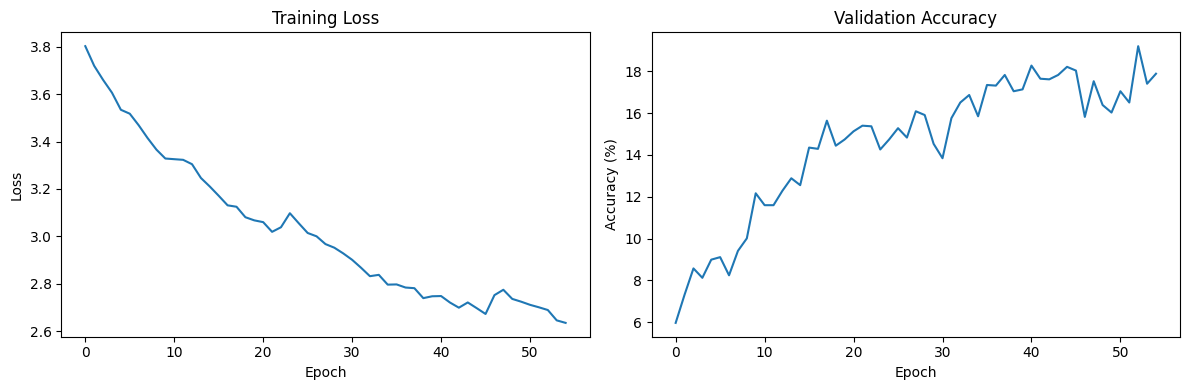


Final Results:
Best Validation Accuracy: 19.21%
Best Validation F1 Score: 18.05%


In [22]:
#  Train the model
NUM_EPOCHS = 100
device = torch.device("cpu")
print(f"Using device: {device}")
print("Starting training...")
best_acc, best_f1 = train_and_evaluate_improved(
    train_loader=train_loader,
    val_loader=val_loader,
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    scheduler=scheduler,
    num_classes=NUM_CLASSES,
    num_epochs=NUM_EPOCHS,
    early_stopping=early_stopping
)

print(f"\nFinal Results:")
print(f"Best Validation Accuracy: {best_acc:.2f}%")
print(f"Best Validation F1 Score: {best_f1:.2f}%")